In [1]:
#Run imports for libraries to be used
import pandas as pd
import json

from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from pandas.core.common import random_state
from sklearn.experimental import enable_iterative_imputer
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import PowerTransformer
import re
import missingno as msno
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import sklearn
from scipy.cluster.hierarchy import fcluster
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer

#Set up options for pandas return functions
pd.options.display.max_rows = 100
pd.options.display.max_columns = 110
sklearn.set_config(transform_output="pandas")

In [2]:
def load_data():
    #load the schema
    with open('ingest_schema.json') as f:
        schema = json.load(f)

    #Use the schema and other params to ingest the csv
    df = pd.read_csv(
        filepath_or_buffer ="CW_data.csv",
        encoding='ANSI',
        dtype = schema,
        true_values = ["positive", "detected", "TRUE", 'present'],
        false_values = ["negative", "not_detected", "FALSE", 'absent'],
        na_values = ["not_done", "<NA>"],
        on_bad_lines = "warn"
        )
    # Remove occurrences of \xa0
    df.columns = [re.sub(r'\s+', ' ', col).strip() for col in df.columns]
    # drop useless columns
    df.drop('Patient ID', axis = 1, inplace = True)
    df_single_values =  df.loc[:, df.nunique(dropna = False) == 1]
    df = df.drop(columns = df_single_values.columns)
    #Ignore the patient quantile and exam result and drop rows that have all other feats as NaN
    ignored_cols = ["Patient age quantile", "SARS-Cov-2 exam result"]
    all_feats_cols = df.columns.difference(ignored_cols)
    df = df.dropna(how = "all", subset = all_feats_cols)
    # Handle categoric and other dtype columns
    df['feat_Urine - Leukocytes'] = df['feat_Urine - Leukocytes'].replace('<1000', 999).astype('Float64')
    mapping = { 'normal': 0, 'Ausentes' : 0}
    df = df.replace(mapping)
    #columns that have categorical data with unknown relationships i.e. if ordinal or not.
    categorical_cols = ['feat_Urine - Aspect','feat_Urine - Crystals','feat_Urine - Color']
    # utilise one-hot encoding to make these columns split out into numeric values columns instead.
    df = pd.get_dummies(
                    df,
                    columns = categorical_cols,
                    dummy_na = True,
                    prefix = categorical_cols,
                    dtype = 'boolean'
                    )
    df = df.apply(pd.to_numeric)
    return df

In [3]:
def tt_split(df, size):
    df_classifiers = df['SARS-Cov-2 exam result']
    df_predictors = df.drop(['SARS-Cov-2 exam result'], axis = 1).copy()
    df_predictor_train, df_predictor_test, df_classifier_train, df_classifier_test = train_test_split(df_predictors, df_classifiers, test_size = size, stratify = df_classifiers, random_state = 1)
    return df_predictor_train, df_predictor_test, df_classifier_train, df_classifier_test

In [4]:
def create_xgb_model(n_estimators, learning_rate, depth, reg_alpha, reg_lambda):
    xgb_model = XGBClassifier(n_estimators = n_estimators, learning_rate = learning_rate, random_state = 1, n_jobs = -1, reg_alpha = reg_alpha, reg_lambda = reg_lambda, max_depth = depth)
    return xgb_model

In [5]:
def create_rf_model(n_estimators = None, max_features = None, max_depth = None):
    rf_model = RandomForestClassifier(n_estimators = n_estimators, max_features = max_features, max_depth = max_depth)
    return rf_model

In [6]:
def create_imba_rf_model():
    rf_model = BalancedRandomForestClassifier()
    return rf_model

In [7]:
def create_ensemble_model():
    eec = EasyEnsembleClassifier()
    return eec

In [8]:
# inputs: threshold - integer between 0 and 1, corresponding to percent to drop (0.05 = 95%)
def missingness_thresholder(df_train,df_test, threshold):
    df_train.dropna(axis = 1, inplace=True, thresh = int(threshold * len(df_train)))
    keep_cols = df_train.columns
    df_test.drop(inplace = True, columns = df_test.columns.difference(keep_cols))
    return df_train, df_test

In [9]:
def missingness_imputer(df_train,df_test, imputer_type, imputer_strategy):
    boolean_cols = df_train.select_dtypes(include = 'boolean').columns
    if imputer_type == 'iterative':
        imputer = IterativeImputer(max_iter = 50, random_state = 1, initial_strategy = imputer_strategy)
        imputer.set_output(transform = "pandas")
        imputer.fit(df_train)
        df_train_imputed = imputer.transform(df_train)
        df_test_imputed = imputer.transform(df_test)
    elif imputer_type == 'simple':
        imputer = SimpleImputer(strategy = imputer_strategy)
        imputer.set_output(transform = "pandas")
        imputer.fit(df_train)
        df_train_imputed = imputer.transform(df_train)
        df_test_imputed = imputer.transform(df_test)
    else:
        df_train = df_train.astype('float64')
        df_test = df_test.astype('float64')
        df_train_imputed = df_train.fillna(value = 0, inplace = True)
        df_test_imputed = df_test.fillna(value = 0, inplace = True)
    df_train_imputed[boolean_cols] = df_train_imputed[boolean_cols].astype(bool)
    df_test_imputed[boolean_cols] = df_test_imputed[boolean_cols].astype(bool)
    return df_train_imputed, df_test_imputed

In [10]:
def skew_transformer(df_train,df_test):
    transformer = PowerTransformer(method = 'yeo-johnson')
    transformer.set_output(transform="pandas")
    numeric_cols = df_train.select_dtypes(exclude = ['boolean']).columns
    train_trans = transformer.fit_transform(df_train[numeric_cols].astype(float))
    test_trans = transformer.transform(df_test[numeric_cols].astype(float))
    df_train[numeric_cols] = train_trans
    df_test[numeric_cols] = test_trans
    return df_train, df_test

In [11]:
def constant_col_drop(df_train,df_test):
    constant_cols = df_train.columns[df_train.nunique() <= 1].tolist()
    df_train.drop(constant_cols, axis = 1, inplace = True)
    df_test.drop(constant_cols, axis = 1, inplace = True)
    return df_train, df_test

In [12]:
def pca_reduction(df_train,df_test, components):
    pca = PCA(n_components = components)
    pca.set_output(transform = "pandas")
    df_train_pca = pca.fit_transform(df_train)
    df_test_pca = pca.transform(df_test)
    return df_train_pca, df_test_pca

In [13]:
def oversampler(df_train,df_classifier, oversampler_type, oversampler_strategy):
    if oversampler_type == 'random':
        oversampler = RandomOverSampler(random_state = 1)
        df_train_oversampled, df_classifier_oversampled = oversampler.fit_resample(df_train, df_classifier)
    elif oversampler_type == 'smote':
        oversampler = SMOTE(sampling_strategy = oversampler_strategy, random_state =1)
        df_train_oversampled, df_classifier_oversampled = oversampler.fit_resample(df_train, df_classifier)
    elif oversampler_type == 'adasyn':
        oversampler = ADASYN(random_state = 1)
        df_train_oversampled, df_classifier_oversampled = oversampler.fit_resample(df_train, df_classifier)
    else:
        print('Invalid oversampler type')
        return df_train, df_classifier
    return df_train_oversampled, df_classifier_oversampled

In [14]:
# builds models quickly with only specific preprocessing enabled
def preprocess(
        dfx,
        dfy,
        dfx_test,
        msn_thresh = False,
        msn_thresh_val = None,
        impute = True,
        imputer_type = None,
        imputer_strategy = None,
        unskew = False,
        pca_reduce = False,
        pca_components = None,
        oversample = False,
        oversampling_type = None,
        oversampling_strategy = None,
        ):
    if msn_thresh:
        dfx, dfx_test = missingness_thresholder(dfx, dfx_test, msn_thresh_val)
    if impute:
        dfx, dfx_test = missingness_imputer(df_train = dfx,  df_test = dfx_test, imputer_type= imputer_type,imputer_strategy= imputer_strategy)
    if unskew:
        dfx, dfx_test = skew_transformer(dfx, dfx_test)
        dfx, dfx_test = constant_col_drop(dfx, dfx_test)
    if pca_reduce:
        dfx, dfx_test = pca_reduction(dfx, dfx_test, pca_components)
    if oversample:
        dfx, dfy = oversampler(dfx, dfy, oversampling_type, oversampling_strategy)
    return dfx, dfx_test, dfy


In [15]:
def model_predict(fitted_model, dfx_test, dfy_test):
    predictions = fitted_model.predict(dfx_test)
    score = fitted_model.score(dfx_test, dfy_test)
    f1 = f1_score(predictions, dfy_test, average = 'macro')
    model_name = fitted_model.__class__.__name__
    print(f'{model_name} score is \n{score}\n {model_name} f1 is \n{f1}')
    return predictions, score, f1, model_name

In [16]:
def compare_models(models, dfx_test, dfy_test):
    results = []
    for model in models:
        predictions, score, f1, model_name = model_predict(model, dfx_test, dfy_test)
        results.append({
            'Model': model_name,
            'Accuracy': score,
            'F1-Score': f1
        })
    # build a melted df to plot results.
    df_results = pd.DataFrame(results)
    df_plot = df_results.melt(id_vars='Model', var_name='Metric', value_name='Value')
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_plot, x='Model', y='Value', hue='Metric')
    plt.title('Model Performance Comparison')
    plt.ylim(0, 1.1) # Limits to show 0-100% range
    plt.ylabel('Score')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    return df_results


In [17]:
def print_cm(dfy_test, predictions, model_name):
    cm = confusion_matrix(dfy_test, predictions)
    plt.figure(figsize = (5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Covid Result')
    plt.ylabel('True Covid Result')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

In [ ]:
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
fitted_models = []
unfitted_models = [
    create_rf_model(n_estimators= 200),
    create_xgb_model(n_estimators = 200, learning_rate = 0.01475912489778882, depth = 2, reg_alpha= 0.00010302549354488498, reg_lambda= 0.00030548927496057773),
    create_ensemble_model(),
    create_imba_rf_model()
]
processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx, dfx_test= dfx_test, dfy = dfy, impute= True, imputer_strategy= 'none', imputer_type= 'none')
for unfitted_model in unfitted_models:
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, dfx_test, dfy_test)


## Base line

## All preprocessing enabled
Missing threshold of 97%
Imputer type simple


C:\Users\Jess\AppData\Local\Temp\ipykernel_28124\2057621469.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


RandomForestClassifier score is 
0.6889632107023411
 RandomForestClassifier f1 is 
0.5058905058905059
XGBClassifier score is 
0.5250836120401338
 XGBClassifier f1 is 
0.43921703296703296
BalancedRandomForestClassifier score is 
0.6789297658862876
 BalancedRandomForestClassifier f1 is 
0.47266313932980597


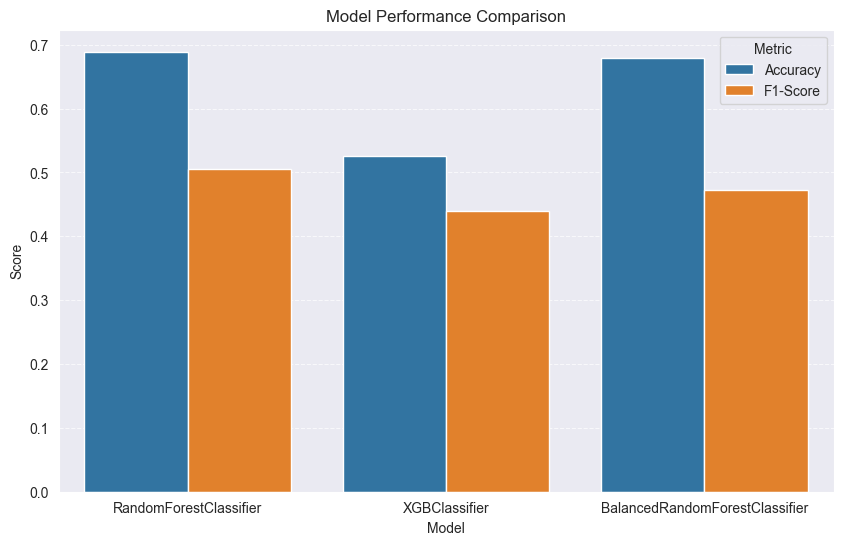

,Model,Accuracy,F1-Score
0,RandomForestClassifier,0.688963,0.505891
1,XGBClassifier,0.525084,0.439217
2,BalancedRandomForestClassifier,0.678930,0.472663


In [19]:
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)
fitted_models = []
unfitted_models = [
    create_rf_model(n_estimators= 200),
    create_xgb_model(n_estimators = 200, learning_rate = 0.01475912489778882, depth = 2, reg_alpha= 0.00010302549354488498, reg_lambda= 0.00030548927496057773),
    create_imba_rf_model()
]
processed_dfx, processed_dfx_test, processed_dfy = preprocess(dfx = dfx,
                                                              dfx_test= dfx_test,
                                                              dfy = dfy,
                                                              msn_thresh= True,
                                                              msn_thresh_val= 0.03,
                                                              impute = True,
                                                              imputer_type = 'simple',
                                                              imputer_strategy = 'median',
                                                              unskew= True,
                                                              pca_reduce= True,
                                                              pca_components= 5,
                                                              oversample= True,
                                                              oversampling_type = 'random',
                                                              oversampling_strategy= 'minority'
                                                              )
for unfitted_model in unfitted_models:
    unfitted_model.fit(processed_dfx, processed_dfy)
    fitted_models.append(unfitted_model)
compare_models(fitted_models, processed_dfx_test, dfy_test)

In [ ]:
from skopt.space import Real, Integer
from scipy.stats import uniform,poisson
from skopt import BayesSearchCV
parameters = {
    'n_estimators':Integer(50,1000,prior='uniform'),
    'learning_rate':Real(0.0001,1, prior ='log-uniform'),
    'max_depth':Integer(1,10,prior='uniform'),
    'reg_alpha':Real(0.0001,2,prior='log-uniform'),
    'reg_lambda':Real(0.0001,2,prior='log-uniform'),
}
b_opt = BayesSearchCV(XGBClassifier(random_state =1), parameters, cv = 5, n_jobs = -1, n_iter = 10)
b_opt.fit(dfxt, dfyt)

best_params = b_opt.best_params_
best_params

In [20]:
from skopt.space import Real, Integer
from scipy.stats import uniform,poisson
from skopt import BayesSearchCV
dfx, dfx_test, dfy ,dfy_test = tt_split(load_data(),0.2)

parameters = {
    'n_estimators':Integer(50,1000,prior='uniform'),
    'learning_rate':Real(0.0001,1, prior ='log-uniform'),
    'max_depth':Integer(1,10,prior='uniform'),
    'reg_alpha':Real(0.0001,2,prior='log-uniform'),
    'reg_lambda':Real(0.0001,2,prior='log-uniform'),
}
b_opt = BayesSearchCV(XGBClassifier(random_state =1), parameters, cv = 5, n_jobs = -1, n_iter = 10)
b_opt.fit(dfx, dfy)

best_params = b_opt.best_params_
best_params

C:\Users\Jess\AppData\Local\Temp\ipykernel_28124\2057621469.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


OrderedDict([('learning_rate', 0.007552430514756118),
             ('max_depth', 2),
             ('n_estimators', 892),
             ('reg_alpha', 0.1152779699122898),
             ('reg_lambda', 0.00031870202503584425)])